# 10 · Fine-tuning strategy comparison (588689)

Head fine-tuning needs you to pick *which* labelled compounds to train on. This notebook compares strategies on two axes:

- **Budget** - `top-N` (label the N highest-ranked compounds, the paper's default) at N = 40, 100, 300, 600, 1000. Does more data keep helping, or saturate?
- **Composition** - at a *fixed* budget (N=300 and N=600), does a smarter selection beat naive top-N? Strategies: `random`, `balanced` (equal active/inactive), `hardneg` (hard negatives), `diverse` (scaffold-spread), `stratified`, `actdiv` (activity-diverse).

**Held-out eval.** All strategies are scored on the same held-out set - compounds ranked **below 1000** (~48,985), disjoint from the top-1000 selection pool - so a strategy cannot win by having memorised its own training region. Numbers are seed means over 5 seeds; error bars are seed SD.

*This notebook reads the live eval CSVs; it fills in as the 70 variant arms finish scoring.*

In [1]:

from pathlib import Path
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
BLK="#000000"; TOP="#2a78d6"; ALT="#eb6834"; PAL=["#2a78d6","#eb6834","#1baf7a","#9467bd","#d62728","#8c564b","#e377c2"]
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
A=Path("/global/scratch/users/sergiomar10/boltzaff/results/analysis/588689")
def rd(name):
    p=A/name
    if not p.exists(): return pd.DataFrame()
    try: return pd.read_csv(p)
    except Exception: return pd.DataFrame()   # empty file (no rows yet)
per=rd("variants_per_seed.csv"); spread=rd("variants_spread.csv"); comp=rd("variants_compare.csv")
NAMES={"ap":"AP (AUPRC)","ef1":"EF@1%","bedroc":"BEDROC(a=20)"}
STRAT_LABEL={"top":"top-N (paper default)","random":"random","balanced":"balanced act/inact",
  "hardneg":"hard negatives","diverse":"diverse (scaffold)","stratified":"stratified","actdiv":"active-diverse"}
if len(spread):
    print("conditions with >=1 complete seed:", len(spread))
    print(spread[["cond","strategy","n_train","n_seeds"]].to_string(index=False))
else:
    print("variant eval not yet available - run pipeline_local/eval_variants.py once arms finish scoring.")


conditions with >=1 complete seed: 14
           cond   strategy  n_train  n_seeds
        top_N40        top       40        5
       top_N100        top      100        5
    actdiv_N300     actdiv      300        5
  balanced_N300   balanced      300        5
   diverse_N300    diverse      300        5
   hardneg_N300    hardneg      300        5
    random_N300     random      300        5
stratified_N300 stratified      300        5
       top_N300        top      300        5
  balanced_N600   balanced      600        5
   diverse_N600    diverse      600        5
   hardneg_N600    hardneg      600        5
       top_N600        top      600        5
      top_N1000        top     1000        5


## A. Budget curve - does more labelled data keep helping?
`top-N` head-FT across budgets. If the curve keeps rising, more labels pay off; if it flattens, there are diminishing returns and 300 is 'enough'.

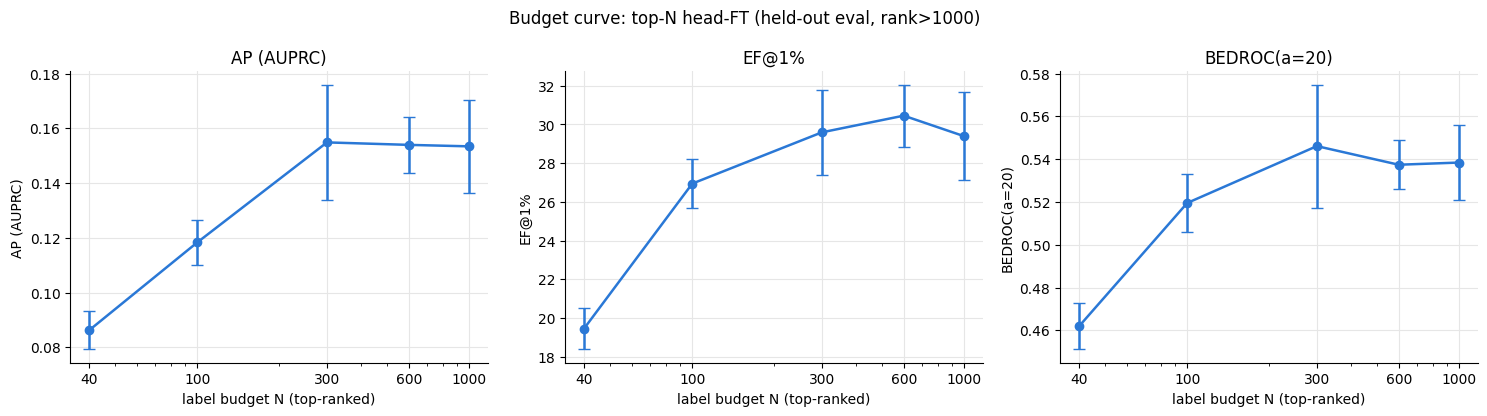

,n_train,n_seeds,ap_mean,ap_sd,ef1_mean,ef1_sd,bedroc_mean
0,40,5,0.0862,0.0070,19.4642,1.0828,0.4619
1,100,5,0.1183,0.0081,26.9454,1.2518,0.5195
8,300,5,0.1549,0.0211,29.5936,2.2032,0.5461
12,600,5,0.1540,0.0102,30.4543,1.6047,0.5374
13,1000,5,0.1534,0.0171,29.3950,2.2621,0.5384


In [2]:
sub=spread[spread.strategy=="top"].sort_values("n_train") if len(spread) else spread
if len(sub)>=2:
    fig,axes=plt.subplots(1,3,figsize=(15,4.2))
    for ax,(k,nm) in zip(axes,NAMES.items()):
        ax.errorbar(sub.n_train,sub[f"{k}_mean"],yerr=sub[f"{k}_sd"],marker="o",color=TOP,capsize=4,lw=1.8)
        ax.set_xlabel("label budget N (top-ranked)"); ax.set_ylabel(nm); ax.set_title(nm); ax.set_xscale("log")
        ax.set_xticks(sub.n_train); ax.set_xticklabels(sub.n_train.astype(int))
    fig.suptitle("Budget curve: top-N head-FT (held-out eval, rank>1000)",fontsize=12); plt.tight_layout(); plt.show()
    display(sub[["n_train","n_seeds","ap_mean","ap_sd","ef1_mean","ef1_sd","bedroc_mean"]].round(4))
else:
    print("need >=2 top-N budgets complete; currently:", list(sub.n_train) if len(sub) else "none")

## B1. Composition at N=300 - does a smarter pick beat top-N?
All selection strategies at the same 300-label budget. The dashed line is top-N (the default). Bars above it are strategies that beat simply labelling the highest-ranked compounds.

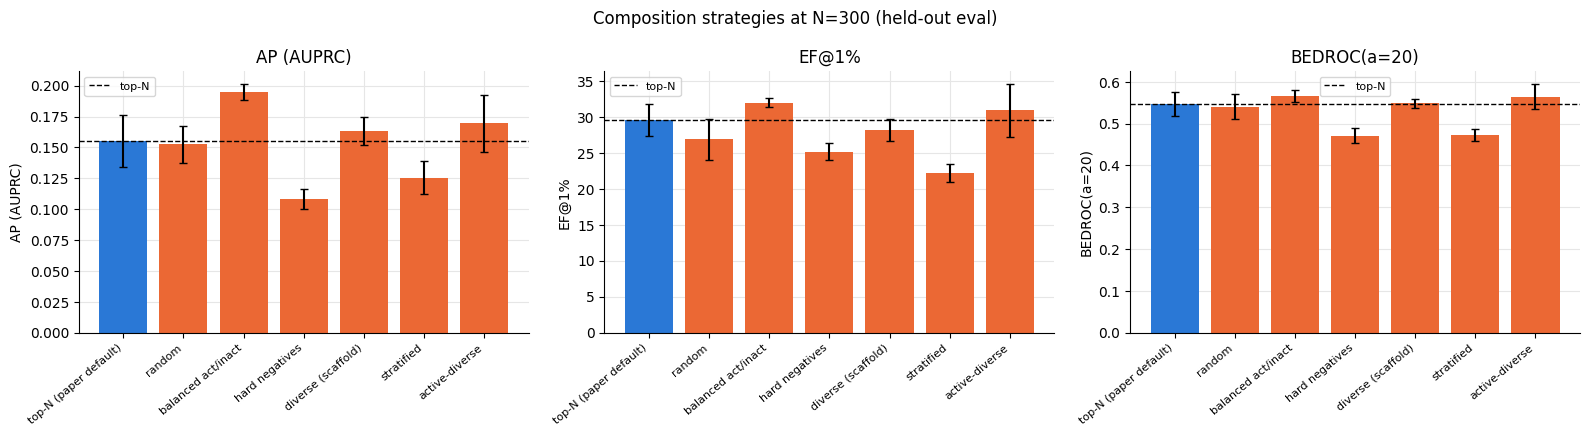

In [3]:
def comp_panel(N):
    sub=spread[(spread.n_train==N)].copy()
    if len(sub)<2: print(f"N={N}: need >=2 strategies complete; have", list(sub.strategy)); return
    order=["top","random","balanced","hardneg","diverse","stratified","actdiv"]
    sub["ord"]=sub.strategy.map({s:i for i,s in enumerate(order)}); sub=sub.sort_values("ord")
    fig,axes=plt.subplots(1,3,figsize=(16,4.4))
    for ax,(k,nm) in zip(axes,NAMES.items()):
        top_v=sub[sub.strategy=="top"][f"{k}_mean"]
        cols=[TOP if s=="top" else ALT for s in sub.strategy]
        ax.bar(range(len(sub)),sub[f"{k}_mean"],yerr=sub[f"{k}_sd"],capsize=3,color=cols)
        if len(top_v): ax.axhline(top_v.iloc[0],ls="--",color=BLK,lw=1,label="top-N")
        ax.set_xticks(range(len(sub))); ax.set_xticklabels([STRAT_LABEL.get(s,s) for s in sub.strategy],rotation=40,ha="right",fontsize=8)
        ax.set_ylabel(nm); ax.set_title(nm); ax.legend(fontsize=8)
    fig.suptitle(f"Composition strategies at N={N} (held-out eval)",fontsize=12); plt.tight_layout(); plt.show()
comp_panel(300)

## B2. Composition at N=600
Same comparison at the larger 600-label budget (top vs balanced / hard-neg / diverse).

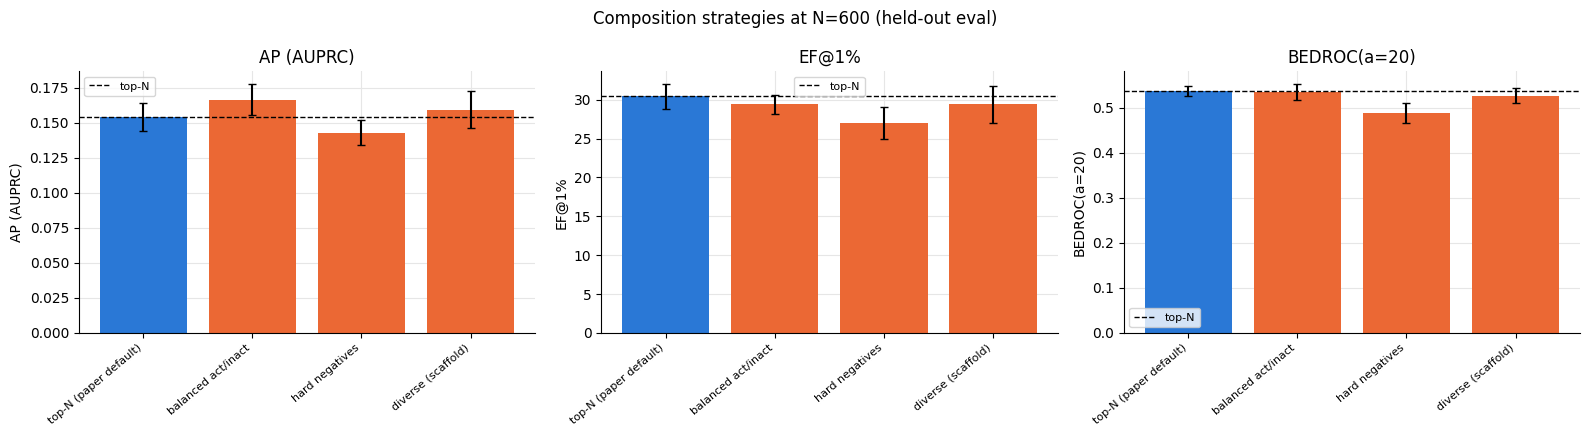

In [4]:
comp_panel(600)

## C. Strategy vs top-N - ratio and significance
From `variants_compare.csv`: each strategy's seed-mean metric divided by top-N at the same budget (ratio > 1 = beats top-N), with a paired-over-seeds t-test p-value. This is the direct answer to 'is composition worth it?'

metric,n_train,strategy,AP,BEDROC,EF1
0,300,actdiv,1.094,1.034,1.041
1,300,balanced,1.268,1.037,1.083
2,300,diverse,1.061,1.005,0.954
3,300,hardneg,0.703,0.863,0.851
4,300,random,0.988,0.991,0.906
5,300,stratified,0.813,0.866,0.752
6,600,balanced,1.082,0.996,0.966
7,600,diverse,1.034,0.980,0.964
8,600,hardneg,0.929,0.910,0.886


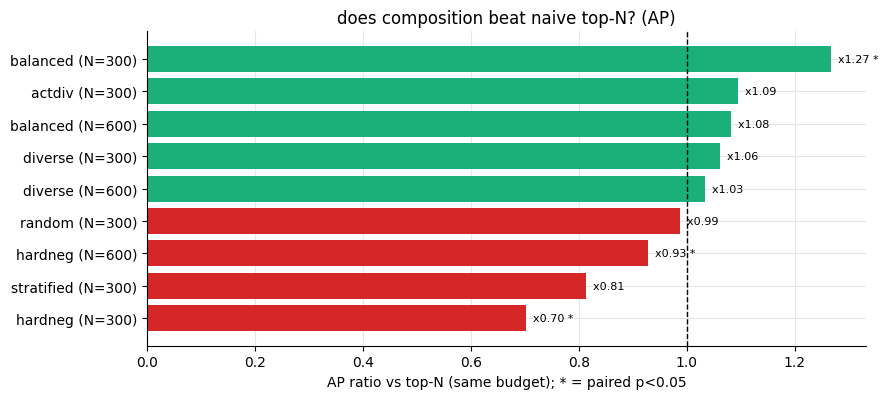

In [5]:
if len(comp):
    piv=comp.pivot_table(index=["n_train","strategy"],columns="metric",values="ratio_vs_top").reset_index()
    display(piv.round(3))
    sub=comp[comp.metric=="AP"].copy()
    if len(sub):
        sub["lab"]=sub.strategy+" (N="+sub.n_train.astype(str)+")"
        sub=sub.sort_values("ratio_vs_top")
        fig,ax=plt.subplots(figsize=(9,0.5+0.4*len(sub)))
        cols=["#1baf7a" if r>1 else "#d62728" for r in sub.ratio_vs_top]
        ax.barh(sub.lab,sub.ratio_vs_top,color=cols)
        ax.axvline(1,ls="--",color=BLK,lw=1)
        for y,(r,p) in enumerate(zip(sub.ratio_vs_top,sub.paired_p)):
            ax.text(r,y,f"  x{r:.2f}"+(" *" if (p==p and p<0.05) else ""),va="center",fontsize=8)
        ax.set_xlabel("AP ratio vs top-N (same budget); * = paired p<0.05")
        ax.set_title("does composition beat naive top-N? (AP)"); plt.tight_layout(); plt.show()
else:
    print("variants_compare.csv not available yet")

## D. Seed spread by condition
Within-condition seed SD - so any strategy difference can be read against the noise floor.

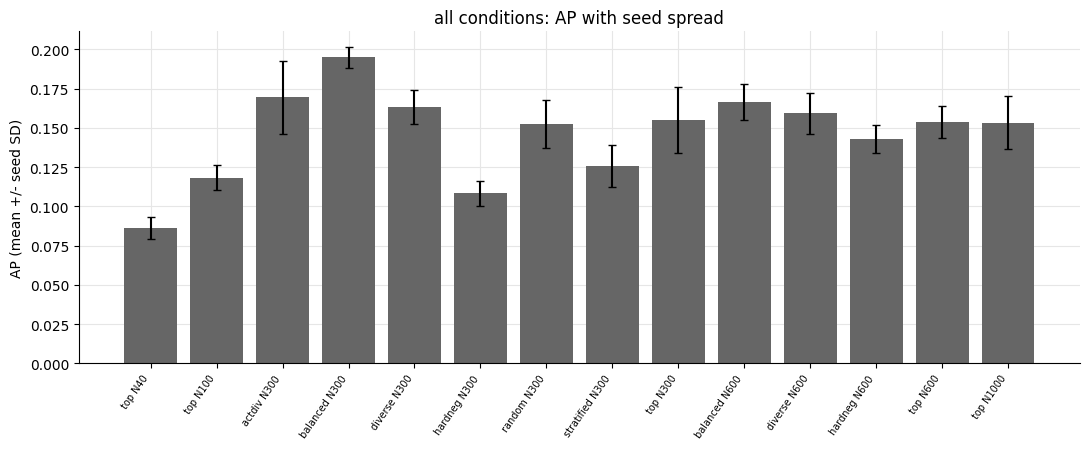

In [6]:
if len(spread):
    s=spread.sort_values(["n_train","strategy"]).copy()
    s["label"]=s.strategy+" N"+s.n_train.astype(str)
    fig,ax=plt.subplots(figsize=(11,4.6))
    ax.bar(range(len(s)),s.ap_mean,yerr=s.ap_sd,capsize=3,color="#666666")
    ax.set_xticks(range(len(s))); ax.set_xticklabels(s.label,rotation=55,ha="right",fontsize=7)
    ax.set_ylabel("AP (mean +/- seed SD)"); ax.set_title("all conditions: AP with seed spread")
    plt.tight_layout(); plt.show()
else: print("no spread data yet")

## Summary (all 70 arms, 5 seeds each, held-out rank>1000 evaluation)

- **Budget.** Top-N AP is 0.086 at N=40, 0.118 at N=100, 0.155 at N=300, 0.154 at N=600 and 0.153 at N=1000, so it saturates at N=300.
- **Composition at N=300** (AP ratio to top-N, paired p over seeds): balanced x1.27 (p=0.028); active-diverse x1.09 (p=0.37); diverse x1.06 (p=0.47); random x0.99 (p=0.91); stratified x0.81 (p=0.10, EF@1% x0.75, p=0.006); hard-negative x0.70 (p=0.012).
- **Composition at N=600:** balanced x1.08 (p=0.053), diverse x1.03 (p=0.60), hard-negative x0.93 (p=0.026). The balanced advantage shrinks as the budget grows, while hard negatives keep hurting.
- **How much to trust it.** Nine strategy-versus-top-N comparisons were run and the p-values are uncorrected. A Bonferroni threshold for nine tests is about 0.006, which neither the balanced gain (0.028) nor the hard-negative penalty (0.012) passes against top-N. The contrast between balanced and hard-negative is far stronger (AP 0.195 vs 0.108, balanced higher in 5 of 5 seeds, paired p<0.0001), so the safest reading is: avoid hard negatives, and balanced selection is promising at a small budget but not established.
- One target, five seeds, and a held-out set of compounds ranked below 1000, so the results describe generalisation, not memorisation of the training region.